[2.21640836e-01 2.22276461e-01 2.22276461e-01 6.24648975e-01
 6.24648975e-01 6.39083937e-01 9.00934728e-01 9.73976376e-01
 9.73976376e-01 1.18838273e+00 1.18838273e+00 1.43027243e+00
 1.44672385e+00 1.75228552e+00 1.75228552e+00 2.12045467e+00
 2.12045467e+00 2.54094019e+00 2.54099711e+00 3.01283577e+00
 3.01283577e+00 3.53555239e+00 3.53555239e+00 4.10883336e+00
 4.10883340e+00 4.73250535e+00 4.73250535e+00 5.40645735e+00
 5.40645735e+00 6.13061541e+00 6.13061541e+00 6.90492862e+00
 6.90492862e+00 7.72936093e+00 7.72936093e+00 8.60388622e+00
 8.60388622e+00 9.52848520e+00 9.52848520e+00 1.05031433e+01
 1.05031433e+01 1.15278495e+01 1.15278495e+01 1.26025951e+01
 1.26025951e+01 1.37273733e+01 1.37273733e+01 1.49021789e+01
 1.49021789e+01 1.61270074e+01 1.61270074e+01 1.74018554e+01
 1.74018554e+01 1.87267201e+01 1.87267201e+01 2.01015991e+01
 2.01015991e+01 2.15264904e+01 2.15264904e+01 2.30013924e+01
 2.30013924e+01 2.45263038e+01 2.45263038e+01 2.61012234e+01
 2.61012234e+01 2.772615

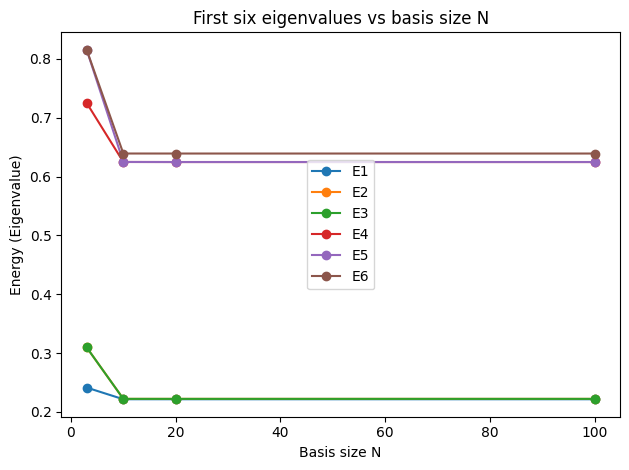

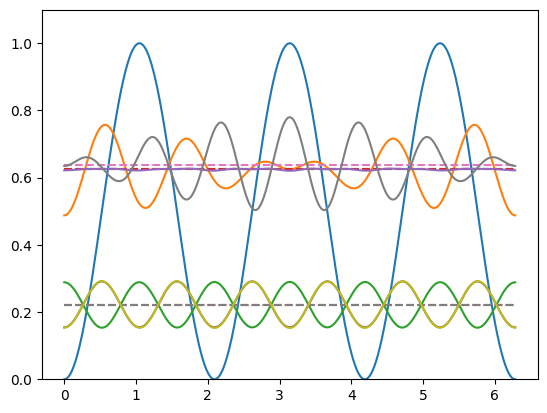

In [ ]:
#Current Version

import numpy as np
import scipy
import pprint
import matplotlib.pyplot as plt

V0 = int(1)
#V0 = 0
I = int(20)


N = [3, 10, 20, 100]


#H = np.zeros((lenH, lenH), dtype = complex)

m = 0
n = 0
Hlist = []

for k in range(0, 4):
  lenH = (2*(N[k]) + 1)
  H = np.zeros((lenH, lenH), dtype = complex)

  n = -N[k]
  m = -N[k]

  for i in range(0, (lenH)):
    m = -N[k]
    for j in range(0, (lenH)):

      if m == n:
        H[i,j] = ((n)**2)/(2*I) + V0/2
        #H[j,i] = ((n)**2)/(2*I) + V0/2
      elif m == (n+3) or m == (n-3):
        H[i,j] =  -V0/4
        #H[j,i] =  -V0/4
      else:
        H[i,j] = 0
        #H[j,i] = 0
      m += 1
    n += 1

  Hlist.append(H)

for i in range (0, 4):
  lenH = (2*(N[k]) + 1)

#np.linalg.eigvalsh


#eigenvalues0, eigenvectors0 = np.linalg.eig(Hlist[0])
#eigenvalues1, eigenvectors1 = np.linalg.eig(Hlist[1])
#eigenvalues2, eigenvectors2 = np.linalg.eig(Hlist[2])
#eigenvalues3, eigenvectors3 = np.linalg.eig(Hlist[3])

eigenvalues0, eigenvectors0 = np.linalg.eigh(Hlist[0])
eigenvalues1, eigenvectors1 = np.linalg.eigh(Hlist[1])
eigenvalues2, eigenvectors2 = np.linalg.eigh(Hlist[2])
eigenvalues3, eigenvectors3 = np.linalg.eigh(Hlist[3])

masterEigenvalues = [eigenvalues0, eigenvalues1, eigenvalues2, eigenvalues3]

#print(eigenvectors0)
#print(eigenvalues0)
#print(eigenvalues1)
#print(eigenvalues2)
print(eigenvalues3)
#print(eigenvectors0)
#print(eigenvectors1)
#print(eigenvectors2)
#print(eigenvectors3)

print("Test", len(eigenvectors3[1])) #<--- Just a small test.

#-------------------------------------------------
for i in range (0, 4):
  print(np.allclose(Hlist[i], Hlist[i].conj().T))
  #print(Hlist[i])
#This part checks if each Hamiltonian matrix is self adjoint.
#If true, it's self adjoint.
#-------------------------------------------------

#Nlist = [3, 10, 20, 100]

masterEigenvalues = [eigenvalues0, eigenvalues1, eigenvalues2, eigenvalues3]

K = 6  # first six eigenvalues
for k in range(K):
    y = [eigs[k] for eigs in masterEigenvalues]   # E_k at each N
    plt.plot(N, y, marker='o', label=f'E{k+1}')



plt.xlabel('Basis size N')
plt.ylabel('Energy (Eigenvalue)')
plt.title('First six eigenvalues vs basis size N')
plt.legend()
plt.tight_layout()
plt.show()


#--------BROKEN-----------
#color = ["blue", "red", "green", "purple"]
#Nplot = []
#Eigenplot =[]
#for i in range (0, 6):
#  for j in range (0, 4):
#    Nplot.append(N[j])
#    Eigenplot.append(masterEigenvalues[j][i])
#
#for i in range(len(Nplot)):
#  j = 0
#  plt.plot(Nplot[i], Eigenplot[i], marker ='o', markerfacecolor = color[j], label=f'E{k+1}')
#  j += 1
#  if j == 4:
#    j = 0


#plt.xlabel('Basis size N')
#plt.ylabel('Energy Eigenvalue')
#plt.title('First six eigenvalues vs basis size N')
#plt.legend()
#plt.tight_layout()
#plt.show()
#--------BROKEN-----------


# -----------------------------------------------------
# Define theta range
# -----------------------------------------------------
num_points = 1000
eigenState = 0
eigenState_list =[]
#theta = np.linspace(-np.pi, np.pi, num_points, endpoint=False)
theta = np.linspace(0, 2 * np.pi, num_points)
#theta201 = np.linspace(0, 2 * np.pi, 201)
V = np.sin(1.5 * theta)**2

plt.figure()
plt.plot(theta, V)

#plt.show()
#plt.plot(theta, V)

for i in range (0, 6):
  energyline = eigenvalues3[i] * np.ones(num_points)
  plt.plot(theta, energyline, linestyle = 'dashed')
  for kk in range(-100, 101):
    #eigenState += (eigenvectors3[i][kk + 100])(np.exp(1j * kk * theta) / np.sqrt(2 * np.pi))
    eigenState += (eigenvectors3[i][kk + 100]) * (np.exp(1j * kk * theta) / np.sqrt(2 * np.pi))

  #eigenState = eigenState/np.sqrt((np.vdot(eigenState, eigenState))) + (eigenvalues3[i]) #<---- (1)
  eigenState = eigenState/np.sqrt((np.vdot(eigenState, eigenState))) #<---- (2)
  eigenState = ((np.abs(eigenState)**2)*2000) - 2 + (eigenvalues3[i])
  #eigenState = 2000*eigenState*eigenState + (eigenvalues3[i])

  #plt.plot(theta, eigenState, num_points) #<---- (1)
  plt.plot(theta, (eigenState), num_points) #<---- (2) Keep in mind that we scale the eigen states by 2000
  #print(eigenState)
  eigenState_list.append(eigenState - (eigenvalues3[i]))
  eigenState = 0
plt.ylim(0, 1.1)
plt.show()




np.savetxt("matrix1.csv", Hlist[0], delimiter=",", fmt="%.6f")
np.savetxt("matrix2.csv", Hlist[1], delimiter=",", fmt="%.6f")
np.savetxt("matrix3.csv", Hlist[2], delimiter=",", fmt="%.6f")
np.savetxt("matrix4.csv", Hlist[3], delimiter=",", fmt="%.6f")


#print(Hlist)

In [ ]:
#print(eigenvectors3[0])
print(np.vdot(eigenState_list[2], eigenState_list[1]))

(-0.009662830790546405+6.28368806592219e-16j)


[0.24147945 0.30970314 0.30970314 0.725      0.81529686 0.81529686
 0.98352055]
[0.22164423 0.22228671 0.22228671 0.62473286 0.62473286 0.63911782
 0.90100145 0.97411458 0.97411458 1.18981241 1.18981241 1.43133723
 1.44775807 1.75304034 1.75304034 2.16270838 2.16270838 2.57954495
 2.57959624 3.04830473 3.04830473]
[ 0.22164084  0.22227646  0.22227646  0.62464897  0.62464897  0.63908394
  0.90093473  0.97397638  0.97397638  1.18838273  1.18838273  1.43027243
  1.44672385  1.75228552  1.75228552  2.12045467  2.12045467  2.5409402
  2.54099711  3.01283577  3.01283577  3.53555239  3.53555239  4.10883375
  4.10883379  4.73250563  4.73250563  5.40645756  5.40645756  6.13073189
  6.13073189  6.90502687  6.90502687  7.72944455  7.72944455  8.62513781
  8.62513781  9.5487126   9.5487126  10.5224399  10.5224399 ]
[2.21640836e-01 2.22276461e-01 2.22276461e-01 6.24648975e-01
 6.24648975e-01 6.39083937e-01 9.00934728e-01 9.73976376e-01
 9.73976376e-01 1.18838273e+00 1.18838273e+00 1.43027243e+00
 1

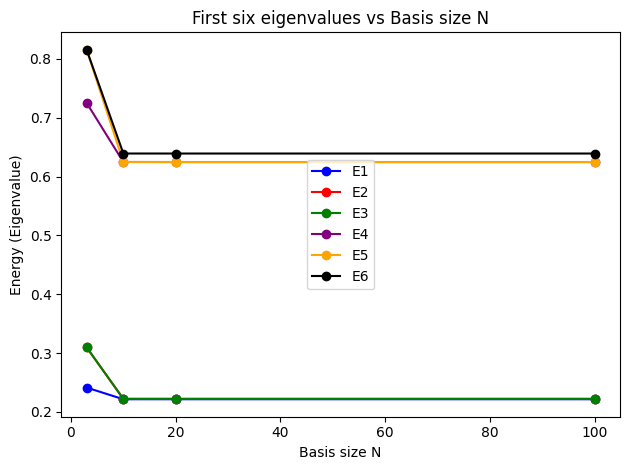

In [ ]:
#Current Version

import numpy as np
import scipy
import pprint
import matplotlib.pyplot as plt

V0 = int(1)
I = int(20)


N = [3, 10, 20, 100]


#H = np.zeros((lenH, lenH), dtype = complex)

m = 0
n = 0
Hlist = []

for k in range(0, 4):
  lenH = (2*(N[k]) + 1)
  H = np.zeros((lenH, lenH), dtype = complex)

  n = -N[k]
  m = -N[k]

  for i in range(0, (lenH)):
    m = -N[k]
    for j in range(0, (lenH)):

      if m == n:
        H[i,j] = ((n)**2)/(2*I) + V0/2
        #H[j,i] = ((n)**2)/(2*I) + V0/2
      elif m == (n+3) or m == (n-3):
        H[i,j] =  -V0/4
        #H[j,i] =  -V0/4
      else:
        H[i,j] = 0
        #H[j,i] = 0
      m += 1
    n += 1

  Hlist.append(H)

for i in range (0, 4):
  lenH = (2*(N[k]) + 1)

#np.linalg.eigvalsh


#eigenvalues0, eigenvectors0 = np.linalg.eig(Hlist[0])
#eigenvalues1, eigenvectors1 = np.linalg.eig(Hlist[1])
#eigenvalues2, eigenvectors2 = np.linalg.eig(Hlist[2])
#eigenvalues3, eigenvectors3 = np.linalg.eig(Hlist[3])

eigenvalues0, eigenvectors0 = np.linalg.eigh(Hlist[0])
eigenvalues1, eigenvectors1 = np.linalg.eigh(Hlist[1])
eigenvalues2, eigenvectors2 = np.linalg.eigh(Hlist[2])
eigenvalues3, eigenvectors3 = np.linalg.eigh(Hlist[3])

masterEigenvalues = [eigenvalues0, eigenvalues1, eigenvalues2, eigenvalues3]
print(eigenvalues0)
print(eigenvalues1)
print(eigenvalues2)
print(eigenvalues3)
print(eigenvectors0)
print(eigenvectors1)
print(eigenvectors2)
print(eigenvectors3)


#-------------------------------------------------
for i in range (0, 4):
  print(np.allclose(Hlist[i], Hlist[i].conj().T))
  print(Hlist[i])
#This part checks if each Hamiltonian matrix is self adjoint.
#If true, it's self adjoint.
#-------------------------------------------------

color = ["blue", "red", "green", "purple"]

#------------------------------------
masterEigenvalues = [np.sort(ev) for ev in masterEigenvalues]

num_levels = 6   # first six eigenvalues
colors = ["blue", "red", "green", "purple", "orange", "black"]

for i in range(num_levels):
    # For each energy level i, collect its value from each N
    energies = [masterEigenvalues[j][i] for j in range(len(N))]
    plt.plot(N, energies, marker='o', color=colors[i % len(colors)], label=f'E{i+1}')

plt.xlabel('Basis size N')
plt.ylabel('Energy (Eigenvalue)')
plt.title('First six eigenvalues vs Basis size N')
plt.legend()
plt.tight_layout()
plt.show()
#-----------------------------------

np.savetxt("matrix1.csv", Hlist[0], delimiter=",", fmt="%.6f")
np.savetxt("matrix2.csv", Hlist[1], delimiter=",", fmt="%.6f")
np.savetxt("matrix3.csv", Hlist[2], delimiter=",", fmt="%.6f")
np.savetxt("matrix4.csv", Hlist[3], delimiter=",", fmt="%.6f")


#print(Hlist)

In [ ]:
#Original
import numpy as np
import scipy
import pprint

V0 = int(1)
I = int(20)


N = [3, 10, 20, 100]


lenH = (2*(N[0])+1)
H = np.zeros((lenH, lenH), dtype = complex)

m = 0
n = 0
Hlist = []
for k in range(0, 4):

  for i in range(0, (lenH)):

    for j in range(0, (lenH)):

      if i == j:
        H[i,j] = ((i-N[0])**2)/(2*I) + V0/2

      elif j == (i+3) or j == (i-3):
        H[i,j] =  -V0/4

      else:
        H[i,j] = 0
  Hlist.append(H)


print(H)

[[ 0.725+0.j  0.   +0.j  0.   +0.j -0.25 +0.j  0.   +0.j  0.   +0.j
   0.   +0.j]
 [ 0.   +0.j  0.6  +0.j  0.   +0.j  0.   +0.j -0.25 +0.j  0.   +0.j
   0.   +0.j]
 [ 0.   +0.j  0.   +0.j  0.525+0.j  0.   +0.j  0.   +0.j -0.25 +0.j
   0.   +0.j]
 [-0.25 +0.j  0.   +0.j  0.   +0.j  0.5  +0.j  0.   +0.j  0.   +0.j
  -0.25 +0.j]
 [ 0.   +0.j -0.25 +0.j  0.   +0.j  0.   +0.j  0.525+0.j  0.   +0.j
   0.   +0.j]
 [ 0.   +0.j  0.   +0.j -0.25 +0.j  0.   +0.j  0.   +0.j  0.6  +0.j
   0.   +0.j]
 [ 0.   +0.j  0.   +0.j  0.   +0.j -0.25 +0.j  0.   +0.j  0.   +0.j
   0.725+0.j]]


In [ ]:
#Failed Fix
import numpy as np
import scipy
import pprint

V0 = int(1)
I = int(20)


N = [3, 10, 20, 100]



H = np.zeros((lenH, lenH), dtype = complex)

m = 0
n = 0
Hlist = []
for k in range(0, 4):
  lenH = (2*(N[k])+1)
  for i in range(0, (lenH)):

    for j in range(0, (lenH)-1):

      if i == j:
        H[i,j] = ((i-N[k]-(k+1))**2)/(2*I) + V0/2

      elif j == (i+3) or j == (i-3):
        H[i,j] =  -V0/4

      else:
        H[i,j] = 0
  Hlist.append(H)



print(H)

IndexError: index 7 is out of bounds for axis 1 with size 7